# 07 — Prédiction des pertes économiques

## Projet USGS Earthquake AI

### Objectif

Construire un modèle de Machine Learning capable d’estimer les pertes économiques causées par un tremblement de terre.

Les informations sur les pertes économiques proviennent de USGS PAGER, tandis que les caractéristiques des séismes proviennent du jeu de données USGS.

### Type de problème

Régression

### Variable cible

Pertes économiques en USD

### Modèles utilisés

1. Régression linéaire
2. Random Forest Regressor
3. Gradient Boosting Regressor

### Variables utilisées

- Magnitude (`mag`)
- Profondeur (`depth`)
- Indice de significativité (`sig`)
- Latitude (`latitude`)
- Longitude (`longitude`)
- Indicateur de tsunami (`tsunami`)

### Évaluation

Les modèles seront comparés avec :

- R²
- MAE
- RMSE

Le meilleur modèle sera sauvegardé afin de pouvoir être réutilisé pour de nouvelles prédictions.

In [1]:
# ============================================================
# IMPORTS AND CONFIGURATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display all DataFrame columns
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# LOAD USGS 2025 EARTHQUAKE DATA
# ============================================================

DATA_PATH = "../data/usgs_earthquakes_2025.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (29062, 35)


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


In [23]:
# ============================================================
# IMPORTS ET CONFIGURATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Afficher toutes les colonnes des DataFrames
pd.set_option("display.max_columns", None)

# Valeur fixe pour obtenir les mêmes résultats à chaque exécution
RANDOM_STATE = 42

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


In [25]:
# ============================================================
# CHARGEMENT DES DONNÉES USGS 2025
# ============================================================

DATA_PATH = "../data/usgs_earthquakes_2025.csv"

# Charger le fichier CSV
df = pd.read_csv(DATA_PATH)

print("Jeu de données chargé avec succès.")
print("Dimensions :", df.shape)

# Afficher les premières lignes
df.head()

Jeu de données chargé avec succès.
Dimensions : (29062, 35)


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


In [27]:
# ============================================================
# VÉRIFICATION DU JEU DE DONNÉES
# ============================================================

print("Nombre de séismes :", len(df))
print("Nombre de colonnes :", len(df.columns))

print("\nColonnes :")
print(df.columns.tolist())

print("\nIdentifiants d'événements en double :")
print(df["event_id"].duplicated().sum())

print("\nIdentifiants d'événements manquants :")
print(df["event_id"].isna().sum())

print("\nPlage des magnitudes :")
print("Minimum :", df["mag"].min())
print("Maximum :", df["mag"].max())

print("\nStatistiques sur la magnitude :")
print(df["mag"].describe())

Nombre de séismes : 29062
Nombre de colonnes : 35

Colonnes :
['mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type', 'title', 'longitude', 'latitude', 'depth', 'event_id', 'date_time', 'year', 'month', 'day', 'hour']

Identifiants d'événements en double :
0

Identifiants d'événements manquants :
0

Plage des magnitudes :
Minimum : 2.5
Maximum : 8.8

Statistiques sur la magnitude :
count    29062.000000
mean         3.932225
std          0.844800
min          2.500000
25%          3.100000
50%          4.200000
75%          4.500000
max          8.800000
Name: mag, dtype: float64


In [28]:
# ============================================================
# SÉLECTION DES SÉISMES SIGNIFICATIFS
# ============================================================

SEUIL_MAGNITUDE = 5.0

df_significant = (
    df[df["mag"] >= SEUIL_MAGNITUDE]
    .copy()
    .reset_index(drop=True)
)

print(f"Seuil de magnitude : M{SEUIL_MAGNITUDE}+")
print("Nombre total de séismes :", len(df))
print("Nombre de séismes significatifs :", len(df_significant))

print("\nStatistiques des magnitudes :")
print(df_significant["mag"].describe())

# Afficher quelques séismes sélectionnés
df_significant[
    [
        "event_id",
        "date_time",
        "mag",
        "place",
        "depth",
        "sig",
        "tsunami"
    ]
].head(10)

Seuil de magnitude : M5.0+
Nombre total de séismes : 29062
Nombre de séismes significatifs : 2122

Statistiques des magnitudes :
count    2122.000000
mean        5.311959
std         0.392481
min         5.000000
25%         5.000000
50%         5.200000
75%         5.400000
max         8.800000
Name: mag, dtype: float64


,event_id,date_time,mag,place,depth,sig,tsunami
0,us7000q9hh,2025-06-29 07:11:56.977000+00:00,5.2,"103 km N of Tatsugō, Japan",10.000,416,0
1,us7000q9hc,2025-06-29 06:48:09.211000+00:00,5.3,"162 km SSW of Lorengau, Papua New Guinea",10.000,432,0
2,us7000q9h4,2025-06-29 05:46:35.266000+00:00,5.1,south of Panama,10.000,400,0
3,us7000q9fs,2025-06-29 01:15:25.559000+00:00,5.4,"98 km NNW of Tatsugō, Japan",10.000,449,0
4,us7000q9f3,2025-06-28 22:24:00.294000+00:00,5.2,"56 km NNE of Barkhan, Pakistan",10.000,419,0
5,us7000q9e7,2025-06-28 19:35:22.701000+00:00,5.0,"24 km SSW of Puerto San José, Guatemala",66.310,391,0
6,us7000q9dv,2025-06-28 18:18:20.515000+00:00,5.2,South Sandwich Islands region,35.000,416,0
7,us7000q9d1,2025-06-28 12:40:43.625000+00:00,5.3,"136 km NNW of Tobelo, Indonesia",53.159,432,0
8,us7000q9cb,2025-06-28 09:51:29.828000+00:00,5.1,"288 km NW of Chokurdakh, Russia",10.000,400,0
9,us7000q9b5,2025-06-28 08:32:20.957000+00:00,6.6,Scotia Sea,10.000,670,1


In [29]:
# ============================================================
# CHARGEMENT DES PERTES ÉCONOMIQUES USGS PAGER
# ============================================================

PAGER_PATH = "../data/pager_economic_losses_2025.csv"

# Vérifier que le fichier existe
if not os.path.exists(PAGER_PATH):
    raise FileNotFoundError(
        f"Fichier PAGER introuvable : {PAGER_PATH}"
    )

# Charger les données PAGER
df_pager = pd.read_csv(PAGER_PATH)

print("Jeu de données PAGER chargé avec succès.")
print("Dimensions :", df_pager.shape)

print("\nColonnes :")
print(df_pager.columns.tolist())

print("\nPremières lignes :")
display(df_pager.head())

print("\nValeurs manquantes :")
display(df_pager.isna().sum())

Jeu de données PAGER chargé avec succès.
Dimensions : (2122, 9)

Colonnes :
['event_id', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'place', 'economic_loss']

Premières lignes :


,event_id,mag,depth,sig,latitude,longitude,tsunami,place,economic_loss
0,us7000q9hh,5.2,10.0,416,29.3819,129.4814,0,"103 km N of Tatsugō, Japan",NaN
1,us7000q9hc,5.3,10.0,432,-3.3008,146.5308,0,"162 km SSW of Lorengau, Papua New Guinea",NaN
2,us7000q9h4,5.1,10.0,400,3.8640,-82.6341,0,south of Panama,NaN
3,us7000q9fs,5.4,10.0,449,29.3062,129.3422,0,"98 km NNW of Tatsugō, Japan",0.0
4,us7000q9f3,5.2,10.0,419,30.3495,69.7968,0,"56 km NNE of Barkhan, Pakistan",68378.0



Valeurs manquantes :


event_id            0
mag                 0
depth               0
sig                 0
latitude            0
longitude           0
tsunami             0
place               0
economic_loss    1388
dtype: int64

In [30]:
# ============================================================
# CONSTRUCTION DU JEU DE DONNÉES POUR LE MODÈLE
# ============================================================

df_model = (
    df_pager
    .dropna(subset=["economic_loss"])
    .copy()
    .reset_index(drop=True)
)

print("Nombre total de séismes M5+ :", len(df_pager))
print(
    "Pertes économiques manquantes :",
    df_pager["economic_loss"].isna().sum()
)

print(
    "Séismes avec une estimation de perte économique :",
    len(df_model)
)

print("\nSéismes avec perte nulle :")
print((df_model["economic_loss"] == 0).sum())

print("\nSéismes avec perte positive :")
print((df_model["economic_loss"] > 0).sum())

print("\nStatistiques des pertes économiques :")
print(df_model["economic_loss"].describe())

display(
    df_model[
        [
            "event_id",
            "mag",
            "depth",
            "sig",
            "latitude",
            "longitude",
            "tsunami",
            "place",
            "economic_loss"
        ]
    ].head(10)
)

Nombre total de séismes M5+ : 2122
Pertes économiques manquantes : 1388
Séismes avec une estimation de perte économique : 734

Séismes avec perte nulle :
625

Séismes avec perte positive :
109

Statistiques des pertes économiques :
count    7.340000e+02
mean     9.758211e+07
std      1.996151e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.299175e+10
Name: economic_loss, dtype: float64


,event_id,mag,depth,sig,latitude,longitude,tsunami,place,economic_loss
0,us7000q9fs,5.4,10.000,449,29.3062,129.3422,0,"98 km NNW of Tatsugō, Japan",0.0
1,us7000q9f3,5.2,10.000,419,30.3495,69.7968,0,"56 km NNE of Barkhan, Pakistan",68378.0
2,us7000q9b5,6.6,10.000,670,-60.9793,-38.9672,1,Scotia Sea,0.0
3,us7000q99p,5.5,229.000,465,-19.8818,-176.0335,0,"161 km NNW of Houma, Tonga",0.0
4,us7000q97d,6.0,99.770,594,5.2888,126.0425,0,"65 km E of Sarangani, Philippines",0.0
5,us7000q8tw,6.2,10.000,591,-35.7221,-17.0441,0,southern Mid-Atlantic Ridge,0.0
6,us7000q8l7,5.4,10.000,449,9.4363,93.8934,0,"276 km SSE of Port Blair, India",0.0
7,pr2025175000,5.7,68.000,1100,19.2245,-68.1103,0,"77 km NNE of Punta Cana, Dominican Republic",0.0
8,us7000q8be,5.5,39.859,465,-10.9655,162.6253,0,"95 km SE of Kirakira, Solomon Islands",0.0
9,us7000q8bd,6.2,10.000,596,7.9765,129.9606,0,east of the Philippine Islands,0.0


Événements avec perte nulle : 625 (85.15%)
Événements avec perte positive : 109 (14.85%)

Statistiques après transformation logarithmique :
count    734.000000
mean       1.504756
std        4.375432
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       24.693402
Name: loss_log, dtype: float64


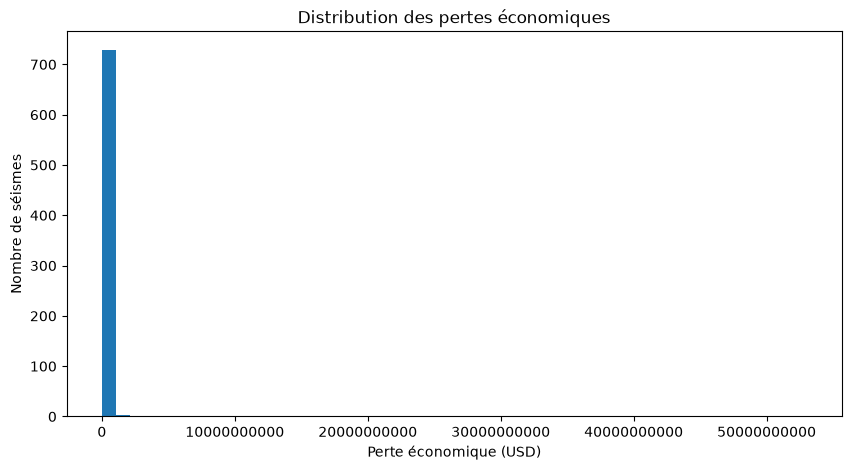

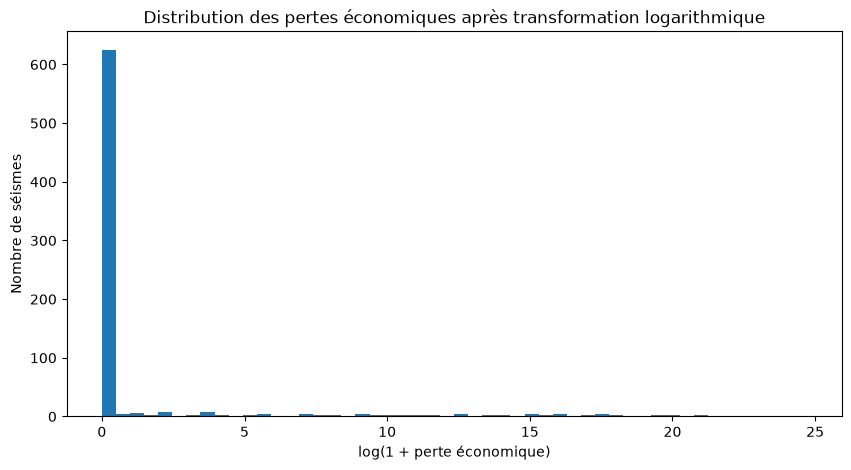

In [31]:
# ============================================================
# ANALYSE DE LA VARIABLE CIBLE
# ============================================================

nb_perte_nulle = (df_model["economic_loss"] == 0).sum()
nb_perte_positive = (df_model["economic_loss"] > 0).sum()

pct_perte_nulle = nb_perte_nulle / len(df_model) * 100
pct_perte_positive = nb_perte_positive / len(df_model) * 100

print(
    f"Événements avec perte nulle : "
    f"{nb_perte_nulle} ({pct_perte_nulle:.2f}%)"
)

print(
    f"Événements avec perte positive : "
    f"{nb_perte_positive} ({pct_perte_positive:.2f}%)"
)

# Transformation logarithmique
df_model["loss_log"] = np.log1p(
    df_model["economic_loss"]
)

print("\nStatistiques après transformation logarithmique :")
print(df_model["loss_log"].describe())

# Distribution des pertes économiques
plt.figure(figsize=(10, 5))

plt.hist(
    df_model["economic_loss"],
    bins=50
)

plt.title("Distribution des pertes économiques")
plt.xlabel("Perte économique (USD)")
plt.ylabel("Nombre de séismes")
plt.ticklabel_format(style="plain", axis="x")

plt.show()

# Distribution après transformation logarithmique
plt.figure(figsize=(10, 5))

plt.hist(
    df_model["loss_log"],
    bins=50
)

plt.title("Distribution des pertes économiques après transformation logarithmique")
plt.xlabel("log(1 + perte économique)")
plt.ylabel("Nombre de séismes")

plt.show()

In [33]:
# ============================================================
# SÉPARATION ENTRAÎNEMENT / TEST
# ============================================================

# 0 = perte nulle
# 1 = perte positive
perte_positive = (
    df_model["economic_loss"] > 0
).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=perte_positive
)

print("Ensemble d'entraînement :", X_train.shape)
print("Ensemble de test :", X_test.shape)

print("\nCible dans l'ensemble d'entraînement :")
print("Perte nulle :", (y_train == 0).sum())
print("Perte positive :", (y_train > 0).sum())

print("\nCible dans l'ensemble de test :")
print("Perte nulle :", (y_test == 0).sum())
print("Perte positive :", (y_test > 0).sum())

print("\nPourcentage de pertes positives :")

print(
    f"Entraînement : "
    f"{(y_train > 0).mean() * 100:.2f}%"
)

print(
    f"Test : "
    f"{(y_test > 0).mean() * 100:.2f}%"
)

Ensemble d'entraînement : (587, 6)
Ensemble de test : (147, 6)

Cible dans l'ensemble d'entraînement :
Perte nulle : 500
Perte positive : 87

Cible dans l'ensemble de test :
Perte nulle : 125
Perte positive : 22

Pourcentage de pertes positives :
Entraînement : 14.82%
Test : 14.97%


In [34]:
# ============================================================
# MODÈLE 1 — RÉGRESSION LINÉAIRE
# ============================================================

modele_lineaire = LinearRegression()

# Entraînement
modele_lineaire.fit(X_train, y_train)

# Prédiction sur l'échelle logarithmique
prediction_lineaire_log = modele_lineaire.predict(X_test)

# R² sur l'échelle logarithmique
r2_lineaire = r2_score(
    y_test,
    prediction_lineaire_log
)

# Retour aux valeurs en USD
y_test_usd = np.expm1(y_test)

prediction_lineaire_usd = np.maximum(
    0,
    np.expm1(prediction_lineaire_log)
)

# MAE
mae_lineaire = mean_absolute_error(
    y_test_usd,
    prediction_lineaire_usd
)

# RMSE
rmse_lineaire = np.sqrt(
    mean_squared_error(
        y_test_usd,
        prediction_lineaire_usd
    )
)

print("RÉGRESSION LINÉAIRE")
print("=" * 40)

print(f"R²   (échelle log) : {r2_lineaire:.4f}")
print(f"MAE  (USD)         : {mae_lineaire:,.2f}")
print(f"RMSE (USD)         : {rmse_lineaire:,.2f}")

RÉGRESSION LINÉAIRE
R²   (échelle log) : 0.5095
MAE  (USD)         : 2,434,711,284,553.52
RMSE (USD)         : 29,519,286,189,096.42


In [35]:
# ============================================================
# ANALYSE DE LA RÉGRESSION LINÉAIRE
# ============================================================

print("PRÉDICTIONS SUR L'ÉCHELLE LOGARITHMIQUE")
print("=" * 45)

print(f"Perte réelle minimale (log)      : {y_test.min():.4f}")
print(f"Perte réelle maximale (log)      : {y_test.max():.4f}")
print(f"Prédiction minimale (log)        : {prediction_lineaire_log.min():.4f}")
print(f"Prédiction maximale (log)        : {prediction_lineaire_log.max():.4f}")

print("\nVALEURS EN USD")
print("=" * 45)

print(
    f"Perte réelle maximale            : "
    f"{y_test_usd.max():,.2f} USD"
)

print(
    f"Prédiction maximale              : "
    f"{prediction_lineaire_usd.max():,.2f} USD"
)

print(
    f"Prédiction médiane               : "
    f"{np.median(prediction_lineaire_usd):,.2f} USD"
)

# Créer un tableau pour analyser les résultats
resultats_lineaire = X_test.copy()

resultats_lineaire["perte_reelle"] = y_test_usd
resultats_lineaire["perte_predite"] = prediction_lineaire_usd
resultats_lineaire["reel_log"] = y_test
resultats_lineaire["prediction_log"] = prediction_lineaire_log

print("\nLes 10 plus grandes prédictions :")

display(
    resultats_lineaire
    .sort_values(
        "perte_predite",
        ascending=False
    )
    .head(10)
)

PRÉDICTIONS SUR L'ÉCHELLE LOGARITHMIQUE
Perte réelle minimale (log)      : 0.0000
Perte réelle maximale (log)      : 24.6934
Prédiction minimale (log)        : -0.9252
Prédiction maximale (log)        : 33.5114

VALEURS EN USD
Perte réelle maximale            : 52,991,751,137.00 USD
Prédiction maximale              : 357,955,316,129,848.81 USD
Prédiction médiane               : 1.13 USD

Les 10 plus grandes prédictions :


,mag,depth,sig,latitude,longitude,tsunami,perte_reelle,perte_predite,reel_log,prediction_log
159,7.70,10.000,2910,22.011000,95.936300,0,5.299175e+10,3.579553e+14,24.693402,33.511429
346,5.40,27.000,1234,23.857800,90.540400,0,2.024465e+07,1.167406e+05,16.823401,11.667718
222,7.60,14.326,1182,17.650600,-82.395000,1,4.200000e+01,1.185303e+04,3.761200,9.380423
123,5.21,14.290,1028,33.035833,-116.594833,1,9.544000e+03,1.067194e+04,9.163773,9.275467
128,5.30,10.000,1023,21.229200,96.089700,0,2.009032e+08,6.618235e+03,19.118334,8.797735
389,6.20,28.000,1042,36.546100,67.388600,0,7.598050e+05,4.063468e+03,13.540818,8.310038
261,6.20,39.000,966,18.501900,-103.363100,0,1.936400e+04,1.227460e+03,9.871223,7.113517
37,5.80,72.000,745,36.725800,28.189100,0,2.000000e+00,7.411213e+01,1.098612,4.318982
251,6.00,16.000,748,23.181600,120.544800,0,2.800000e+01,7.283631e+01,3.367296,4.301851
370,6.80,18.000,724,39.485000,143.378200,1,0.000000e+00,3.822754e+01,0.000000,3.669379


In [13]:
# ============================================================
# MODEL 3 — GRADIENT BOOSTING REGRESSOR
# ============================================================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Train
gb_model.fit(X_train, y_train)

# Predict log-loss
y_pred_gb_log = gb_model.predict(X_test)

# R² on log-transformed target
gb_r2 = r2_score(y_test, y_pred_gb_log)

# Convert predictions back to USD
y_pred_gb_usd = np.maximum(
    0,
    np.expm1(y_pred_gb_log)
)

# Dollar-based metrics
gb_mae = mean_absolute_error(
    y_test_usd,
    y_pred_gb_usd
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test_usd,
        y_pred_gb_usd
    )
)

print("GRADIENT BOOSTING REGRESSOR")
print("=" * 40)

print(f"R²   (log scale): {gb_r2:.4f}")
print(f"MAE  (USD):       ${gb_mae:,.2f}")
print(f"RMSE (USD):       ${gb_rmse:,.2f}")

print("\nPrediction range:")
print(
    f"Predicted log-loss: "
    f"{y_pred_gb_log.min():.4f} to {y_pred_gb_log.max():.4f}"
)

print(
    f"Maximum predicted loss: "
    f"${y_pred_gb_usd.max():,.2f}"
)

GRADIENT BOOSTING REGRESSOR
R²   (log scale): 0.6859
MAE  (USD):       $353,471,422.25
RMSE (USD):       $4,265,751,935.39

Prediction range:
Predicted log-loss: -0.1528 to 20.9644
Maximum predicted loss: $1,272,644,579.71


In [36]:
# ============================================================
# MODÈLE 2 — RANDOM FOREST REGRESSOR
# ============================================================

modele_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Entraînement
modele_rf.fit(X_train, y_train)

# Prédictions sur l'échelle logarithmique
prediction_rf_log = modele_rf.predict(X_test)

# R²
r2_rf = r2_score(
    y_test,
    prediction_rf_log
)

# Retour en USD
prediction_rf_usd = np.maximum(
    0,
    np.expm1(prediction_rf_log)
)

# MAE
mae_rf = mean_absolute_error(
    y_test_usd,
    prediction_rf_usd
)

# RMSE
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_usd,
        prediction_rf_usd
    )
)

print("RANDOM FOREST REGRESSOR")
print("=" * 40)

print(f"R²   (échelle log) : {r2_rf:.4f}")
print(f"MAE  (USD)         : {mae_rf:,.2f}")
print(f"RMSE (USD)         : {rmse_rf:,.2f}")

print("\nPlage des prédictions :")

print(
    f"Prédiction log : "
    f"{prediction_rf_log.min():.4f} à "
    f"{prediction_rf_log.max():.4f}"
)

print(
    f"Perte maximale prédite : "
    f"{prediction_rf_usd.max():,.2f} USD"
)

RANDOM FOREST REGRESSOR
R²   (échelle log) : 0.7092
MAE  (USD)         : 358,050,929.52
RMSE (USD)         : 4,323,670,866.57

Plage des prédictions :
Prédiction log : 0.0000 à 20.1618
Perte maximale prédite : 570,357,926.65 USD


In [37]:
# ============================================================
# MODÈLE 3 — GRADIENT BOOSTING REGRESSOR
# ============================================================

modele_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Entraînement
modele_gb.fit(X_train, y_train)

# Prédictions sur l'échelle logarithmique
prediction_gb_log = modele_gb.predict(X_test)

# R²
r2_gb = r2_score(
    y_test,
    prediction_gb_log
)

# Retour en USD
prediction_gb_usd = np.maximum(
    0,
    np.expm1(prediction_gb_log)
)

# MAE
mae_gb = mean_absolute_error(
    y_test_usd,
    prediction_gb_usd
)

# RMSE
rmse_gb = np.sqrt(
    mean_squared_error(
        y_test_usd,
        prediction_gb_usd
    )
)

print("GRADIENT BOOSTING REGRESSOR")
print("=" * 40)

print(f"R²   (échelle log) : {r2_gb:.4f}")
print(f"MAE  (USD)         : {mae_gb:,.2f}")
print(f"RMSE (USD)         : {rmse_gb:,.2f}")

print("\nPlage des prédictions :")

print(
    f"Prédiction log : "
    f"{prediction_gb_log.min():.4f} à "
    f"{prediction_gb_log.max():.4f}"
)

print(
    f"Perte maximale prédite : "
    f"{prediction_gb_usd.max():,.2f} USD"
)

GRADIENT BOOSTING REGRESSOR
R²   (échelle log) : 0.6859
MAE  (USD)         : 353,471,422.25
RMSE (USD)         : 4,265,751,935.39

Plage des prédictions :
Prédiction log : -0.1528 à 20.9644
Perte maximale prédite : 1,272,644,579.71 USD


In [16]:
# ============================================================
# INSPECT POSITIVE-LOSS PREDICTIONS
# ============================================================

positive_predictions = df_model.loc[
    X_test.index,
    ["event_id", "place", "mag", "sig", "economic_loss"]
].copy()

positive_predictions["RF_Prediction"] = y_pred_rf_usd
positive_predictions["GB_Prediction"] = y_pred_gb_usd

# Keep only earthquakes with real positive economic loss
positive_predictions = positive_predictions[
    positive_predictions["economic_loss"] > 0
].copy()

# Absolute errors
positive_predictions["RF_Error"] = abs(
    positive_predictions["economic_loss"]
    - positive_predictions["RF_Prediction"]
)

positive_predictions["GB_Error"] = abs(
    positive_predictions["economic_loss"]
    - positive_predictions["GB_Prediction"]
)

# Sort by actual economic loss
positive_predictions = positive_predictions.sort_values(
    "economic_loss",
    ascending=False
)

display(
    positive_predictions.style.format({
        "economic_loss": "${:,.2f}",
        "RF_Prediction": "${:,.2f}",
        "GB_Prediction": "${:,.2f}",
        "RF_Error": "${:,.2f}",
        "GB_Error": "${:,.2f}"
    })
)

,event_id,place,mag,sig,economic_loss,RF_Prediction,GB_Prediction,RF_Error,GB_Error
159,us7000pn9s,"2025 Mandalay, Burma (Myanmar) Earthquake",7.700000,2910,"$52,991,751,137.00","$570,357,926.65","$1,272,644,579.71","$52,421,393,210.35","$51,719,106,557.29"
128,us6000q5ps,"41 km S of Kyaukse, Burma (Myanmar)",5.300000,1023,"$200,903,241.00","$15,372,023.04","$2,111,590.84","$185,531,217.96","$198,791,650.16"
346,us6000rpht,"14 km ESE of Tungi, Bangladesh",5.400000,1234,"$20,244,653.00","$26,799,579.20","$34,164,183.46","$6,554,926.20","$13,919,530.46"
525,us7000qr6h,"21 km ENE of Novokayakent, Russia",5.400000,659,"$7,438,346.00","$1,590.48","$375,197.19","$7,436,755.52","$7,063,148.81"
126,us6000q5q8,"42 km ESE of Rasht, Tajikistan",5.800000,673,"$3,965,198.00","$3,124,923.51","$211,539.09","$840,274.49","$3,753,658.91"
280,us7000rl57,"43 km W of Puerto Santa, Peru",6.200000,693,"$783,278.00","$43,608.79","$152,373.79","$739,669.21","$630,904.21"
389,us6000rl31,"30 km SE of Mazār-e Sharīf, Afghanistan",6.200000,1042,"$759,805.00","$10,040,818.31","$16,813,968.23","$9,281,013.31","$16,054,163.23"
464,us6000rdf2,"16 km NNW of Simav, Turkey",5.200000,435,"$327,030.00",$918.82,$33.33,"$326,111.18","$326,996.67"
499,us7000qx1z,"26 km S of Nabire, Indonesia",6.000000,558,"$65,227.00",$0.11,$0.39,"$65,226.89","$65,226.61"
270,us6000phnz,"45 km NNE of Āwash, Ethiopia",5.500000,481,"$35,961.00",$46.16,$8.43,"$35,914.84","$35,952.57"


In [38]:
# ============================================================
# COMPARAISON DES MODÈLES
# ============================================================

comparaison_modeles = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R² (log)": [
        r2_lineaire,
        r2_rf,
        r2_gb
    ],
    "MAE (USD)": [
        mae_lineaire,
        mae_rf,
        mae_gb
    ],
    "RMSE (USD)": [
        rmse_lineaire,
        rmse_rf,
        rmse_gb
    ]
})

# Trier selon le MAE
comparaison_modeles = comparaison_modeles.sort_values(
    "MAE (USD)"
).reset_index(drop=True)

display(
    comparaison_modeles.style.format({
        "R² (log)": "{:.4f}",
        "MAE (USD)": "{:,.2f}",
        "RMSE (USD)": "{:,.2f}"
    })
)

,Modèle,R² (log),MAE (USD),RMSE (USD)
0,Gradient Boosting,0.6859,"353,471,422.25","4,265,751,935.39"
1,Random Forest,0.7092,"358,050,929.52","4,323,670,866.57"
2,Régression linéaire,0.5095,"2,434,711,284,553.52","29,519,286,189,096.42"


In [39]:
# ============================================================
# ÉVALUATION SUR LES PERTES ÉCONOMIQUES POSITIVES
# ============================================================

# Identifier les séismes avec une perte réelle positive
masque_positif = y_test_usd > 0

# Valeurs réelles
y_test_positif = y_test_usd[masque_positif]

# Prédictions des trois modèles
pred_lineaire_positif = prediction_lineaire_usd[masque_positif]
pred_rf_positif = prediction_rf_usd[masque_positif]
pred_gb_positif = prediction_gb_usd[masque_positif]


def calculer_metriques(y_reel, y_pred):
    
    mae = mean_absolute_error(
        y_reel,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_reel,
            y_pred
        )
    )
    
    return mae, rmse


# Régression linéaire
mae_lineaire_pos, rmse_lineaire_pos = calculer_metriques(
    y_test_positif,
    pred_lineaire_positif
)

# Random Forest
mae_rf_pos, rmse_rf_pos = calculer_metriques(
    y_test_positif,
    pred_rf_positif
)

# Gradient Boosting
mae_gb_pos, rmse_gb_pos = calculer_metriques(
    y_test_positif,
    pred_gb_positif
)


comparaison_positive = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE pertes positives (USD)": [
        mae_lineaire_pos,
        mae_rf_pos,
        mae_gb_pos
    ],
    "RMSE pertes positives (USD)": [
        rmse_lineaire_pos,
        rmse_rf_pos,
        rmse_gb_pos
    ]
})

comparaison_positive = comparaison_positive.sort_values(
    "MAE pertes positives (USD)"
).reset_index(drop=True)

print(
    "Nombre de séismes avec une perte positive dans le test :",
    len(y_test_positif)
)

display(
    comparaison_positive.style.format({
        "MAE pertes positives (USD)": "{:,.2f}",
        "RMSE pertes positives (USD)": "{:,.2f}"
    })
)

Nombre de séismes avec une perte positive dans le test : 22


,Modèle,MAE pertes positives (USD),RMSE pertes positives (USD)
0,Gradient Boosting,"2,361,831,721.96","11,026,633,083.39"
1,Random Forest,"2,392,431,191.30","11,176,348,962.87"
2,Régression linéaire,"16,268,298,128,593.16","76,305,031,942,891.58"


In [40]:
# ============================================================
# ANALYSE DES PRÉDICTIONS SUR LES PERTES POSITIVES
# ============================================================

resultats_test = df_model.loc[X_test.index].copy()

resultats_test["perte_reelle"] = y_test_usd
resultats_test["prediction_lineaire"] = prediction_lineaire_usd
resultats_test["prediction_rf"] = prediction_rf_usd
resultats_test["prediction_gb"] = prediction_gb_usd

# Garder uniquement les pertes réellement positives
resultats_positifs = (
    resultats_test[
        resultats_test["perte_reelle"] > 0
    ]
    .copy()
)

# Calculer l'erreur absolue du Gradient Boosting
resultats_positifs["erreur_gb"] = abs(
    resultats_positifs["perte_reelle"]
    - resultats_positifs["prediction_gb"]
)

# Trier par perte réelle décroissante
resultats_positifs = resultats_positifs.sort_values(
    "perte_reelle",
    ascending=False
)

print(
    "Nombre de séismes avec perte positive :",
    len(resultats_positifs)
)

display(
    resultats_positifs[
        [
            "event_id",
            "place",
            "mag",
            "sig",
            "perte_reelle",
            "prediction_rf",
            "prediction_gb",
            "erreur_gb"
        ]
    ].head(15).style.format({
        "perte_reelle": "{:,.2f}",
        "prediction_rf": "{:,.2f}",
        "prediction_gb": "{:,.2f}",
        "erreur_gb": "{:,.2f}"
    })
)

Nombre de séismes avec perte positive : 22


,event_id,place,mag,sig,perte_reelle,prediction_rf,prediction_gb,erreur_gb
159,us7000pn9s,"2025 Mandalay, Burma (Myanmar) Earthquake",7.700000,2910,"52,991,751,137.00","570,357,926.65","1,272,644,579.71","51,719,106,557.29"
128,us6000q5ps,"41 km S of Kyaukse, Burma (Myanmar)",5.300000,1023,"200,903,241.00","15,372,023.04","2,111,590.84","198,791,650.16"
346,us6000rpht,"14 km ESE of Tungi, Bangladesh",5.400000,1234,"20,244,653.00","26,799,579.20","34,164,183.46","13,919,530.46"
525,us7000qr6h,"21 km ENE of Novokayakent, Russia",5.400000,659,"7,438,346.00","1,590.48","375,197.19","7,063,148.81"
126,us6000q5q8,"42 km ESE of Rasht, Tajikistan",5.800000,673,"3,965,198.00","3,124,923.51","211,539.09","3,753,658.91"
280,us7000rl57,"43 km W of Puerto Santa, Peru",6.200000,693,"783,278.00","43,608.79","152,373.79","630,904.21"
389,us6000rl31,"30 km SE of Mazār-e Sharīf, Afghanistan",6.200000,1042,"759,805.00","10,040,818.31","16,813,968.23","16,054,163.23"
464,us6000rdf2,"16 km NNW of Simav, Turkey",5.200000,435,"327,030.00",918.82,33.33,"326,996.67"
499,us7000qx1z,"26 km S of Nabire, Indonesia",6.000000,558,"65,227.00",0.11,0.39,"65,226.61"
270,us6000phnz,"45 km NNE of Āwash, Ethiopia",5.500000,481,"35,961.00",46.16,8.43,"35,952.57"


Importance des variables :


,Variable,Importance
0,sig,0.6902
1,mag,0.1097
2,longitude,0.0989
3,latitude,0.0676
4,depth,0.0314
5,tsunami,0.0022


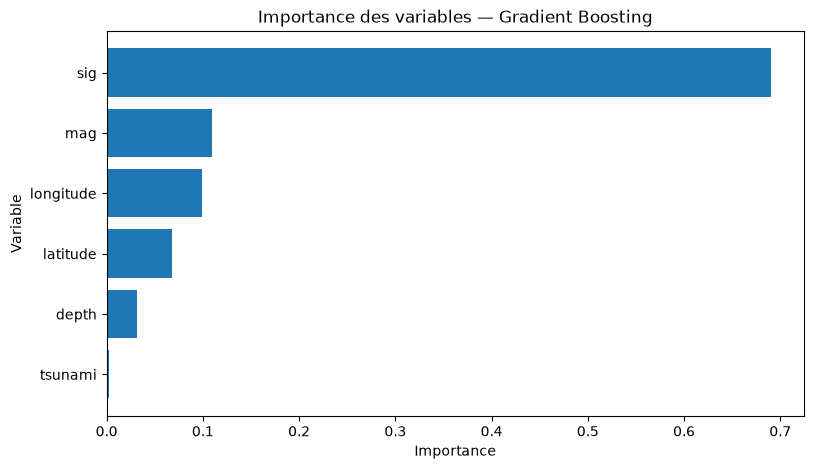

In [41]:
# ============================================================
# IMPORTANCE DES VARIABLES — GRADIENT BOOSTING
# ============================================================

importance_variables = pd.DataFrame({
    "Variable": VARIABLES,
    "Importance": modele_gb.feature_importances_
})

importance_variables = importance_variables.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Importance des variables :")

display(
    importance_variables.style.format({
        "Importance": "{:.4f}"
    })
)

# Graphique
plt.figure(figsize=(9, 5))

plt.barh(
    importance_variables["Variable"][::-1],
    importance_variables["Importance"][::-1]
)

plt.title(
    "Importance des variables — Gradient Boosting"
)

plt.xlabel("Importance")
plt.ylabel("Variable")

plt.show()

In [42]:
# ============================================================
# SAUVEGARDE DU MODÈLE FINAL
# ============================================================

MODEL_PATH = "../models/economic_loss_gradient_boosting.pkl"

# Créer le dossier models s'il n'existe pas
os.makedirs(
    os.path.dirname(MODEL_PATH),
    exist_ok=True
)

# Préparer le package du modèle
package_modele = {
    "model": modele_gb,
    "features": VARIABLES,
    "target": CIBLE,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
    "random_state": RANDOM_STATE,
    "metrics": {
        "r2_log": r2_gb,
        "mae_usd": mae_gb,
        "rmse_usd": rmse_gb,
        "mae_positive_usd": mae_gb_pos,
        "rmse_positive_usd": rmse_gb_pos
    }
}

# Sauvegarder
joblib.dump(
    package_modele,
    MODEL_PATH
)

print("Modèle sauvegardé avec succès.")
print("Fichier :", MODEL_PATH)

print("\nMétriques du modèle final :")
print(f"R²   (log) : {r2_gb:.4f}")
print(f"MAE  (USD) : {mae_gb:,.2f}")
print(f"RMSE (USD) : {rmse_gb:,.2f}")

print(
    "\nLe fichier existe :",
    os.path.exists(MODEL_PATH)
)

Modèle sauvegardé avec succès.
Fichier : ../models/economic_loss_gradient_boosting.pkl

Métriques du modèle final :
R²   (log) : 0.6859
MAE  (USD) : 353,471,422.25
RMSE (USD) : 4,265,751,935.39

Le fichier existe : True


In [43]:
# ============================================================
# SAUVEGARDE DU JEU DE DONNÉES FINAL
# ============================================================

DATASET_PATH = "../data/economic_loss_model_2025.csv"

colonnes_finales = [
    "event_id",
    "place",
    "mag",
    "depth",
    "sig",
    "latitude",
    "longitude",
    "tsunami",
    "economic_loss",
    "loss_log"
]

dataset_final = df_model[
    colonnes_finales
].copy()

# Sauvegarder en CSV
dataset_final.to_csv(
    DATASET_PATH,
    index=False
)

print("Jeu de données sauvegardé avec succès.")
print("Fichier :", DATASET_PATH)

print("\nDimensions :", dataset_final.shape)

print("\nColonnes :")
print(dataset_final.columns.tolist())

print(
    "\nLe fichier existe :",
    os.path.exists(DATASET_PATH)
)

display(dataset_final.head())

Jeu de données sauvegardé avec succès.
Fichier : ../data/economic_loss_model_2025.csv

Dimensions : (734, 10)

Colonnes :
['event_id', 'place', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'economic_loss', 'loss_log']

Le fichier existe : True


,event_id,place,mag,depth,sig,latitude,longitude,tsunami,economic_loss,loss_log
0,us7000q9fs,"98 km NNW of Tatsugō, Japan",5.4,10.00,449,29.3062,129.3422,0,0.0,0.000000
1,us7000q9f3,"56 km NNE of Barkhan, Pakistan",5.2,10.00,419,30.3495,69.7968,0,68378.0,11.132821
2,us7000q9b5,Scotia Sea,6.6,10.00,670,-60.9793,-38.9672,1,0.0,0.000000
3,us7000q99p,"161 km NNW of Houma, Tonga",5.5,229.00,465,-19.8818,-176.0335,0,0.0,0.000000
4,us7000q97d,"65 km E of Sarangani, Philippines",6.0,99.77,594,5.2888,126.0425,0,0.0,0.000000


In [44]:
# ============================================================
# VALIDATION FINALE DU PIPELINE
# ============================================================

print("VALIDATION DU PIPELINE")
print("=" * 50)

# Vérifier les fichiers
print("Modèle présent :", os.path.exists(MODEL_PATH))
print("Dataset présent :", os.path.exists(DATASET_PATH))

# Recharger le modèle
package_charge = joblib.load(MODEL_PATH)

modele_charge = package_charge["model"]
variables_chargees = package_charge["features"]

print("\nType du modèle :")
print(type(modele_charge).__name__)

print("\nVariables du modèle :")
print(variables_chargees)

# Recharger le dataset final
dataset_charge = pd.read_csv(DATASET_PATH)

print("\nDimensions du dataset :")
print(dataset_charge.shape)

# Prendre un exemple du jeu de test
exemple = X_test.iloc[[0]].copy()

print("\nExemple utilisé pour la prédiction :")
display(exemple)

# Faire une prédiction
prediction_log = modele_charge.predict(exemple)[0]

# Revenir en USD
prediction_usd = max(
    0,
    np.expm1(prediction_log)
)

print(
    f"\nPerte prédite sur l'échelle log : "
    f"{prediction_log:.4f}"
)

print(
    f"Perte économique prédite : "
    f"{prediction_usd:,.2f} USD"
)

print("\nPIPELINE DU MODÈLE VALIDÉ AVEC SUCCÈS")

VALIDATION DU PIPELINE
Modèle présent : True
Dataset présent : True

Type du modèle :
GradientBoostingRegressor

Variables du modèle :
['mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami']

Dimensions du dataset :
(734, 10)

Exemple utilisé pour la prédiction :


,mag,depth,sig,latitude,longitude,tsunami
85,6.4,8.0,634,-57.304,-67.0168,1



Perte prédite sur l'échelle log : 2.3168
Perte économique prédite : 9.14 USD

PIPELINE DU MODÈLE VALIDÉ AVEC SUCCÈS


# Conclusion finale

Nous avons comparé trois modèles pour prédire les pertes économiques causées par les séismes : **Régression linéaire, Random Forest et Gradient Boosting**.

**Gradient Boosting a été sélectionné comme modèle final**, avec un **MAE de 353,47 millions USD** et un **RMSE de 4,27 milliards USD**.

Le modèle fonctionne correctement pour la majorité des événements, mais il **sous-estime fortement les pertes économiques extrêmes**. Pour améliorer les prédictions, il faudrait ajouter des informations sur la **population exposée, les bâtiments, les infrastructures et l'activité économique**.